# **AIDA - Big Data Processing and Data Engineering**
*Homework 1/2 - Saporiti Alessandro*
---
---
# **Esplorazione e mappatura di antichi fiumi sepolti in zone desertiche**
Questo notebook implementa una pipeline avanzata per identificare, mappare e contestualizzare geograficamente i letti di antichi fiumi nascosti sotto la superficie desertica. Sfruttando rilevamenti radar per penetrare lo strato sabbioso superficiale, i dati satellitari correttamente elaborati potrebbero rivelare una complessa rete idrografica fossile (paleo-canali) non visibile a occhio nudo. L'integrazione con i dati topografici potrebbero permette di ricostruire l'andamento degli avvallamenti originari, offrendo uno strumento cruciale per studi paleoclimatici, ricerca di risorse idriche sotterranee e indagini archeologiche.


**Approccio Metodologico**

A differenza delle normali fotografie satellitari (ottiche), le microonde dei radar (SAR- Synthetic Aperture Radar), specialmente in banda *L* o *C*, possono penetrare per diversi metri la sabbia finissima e priva di umidità dei deserti. Quando il segnale radar incontra il letto roccioso o i sedimenti più densi dell'antico fiume sepolto, viene riflesso in modo diverso rispetto alla sabbia superficiale.
Anche se un fiume è sepolto, la sua presenza ha modellato il terreno. I modelli digitali di elevazione servono a cercare impercettibili avvallamenti o pendenze che confermano la morfologia di una valle fluviale.

Il notebook esegue una serie di operazioni sequenziali per trasformare dati grezzi e illeggibili, ottenuti tramite rilevamenti radar, in una mappa geologica chiara attraverso alcuni passaggi:

1.  Conversione in scala logaritmica (dB) dei dati grezzi: i dati radar grezzi (backscatter) hanno una gamma dinamica enorme e i valori numerici variano in modo esponenziale. Convertire i dati in decibel comprime questa gamma al fine di rendere visibili i dettagli sia nelle aree che riflettono pochissimo segnale (la sabbia), sia in quelle che ne riflettono molto (la roccia sottostante), linearizzando il contrasto.

2.  De-noising (Rimozione del rumore): le immagini radar sono intrinsecamente affette da un rumore tipico chiamato speckle (l'effetto "sale e pepe"). Applicando filtri digitali si pulisce l'immagine per evitare che il computer scambi il rumore di fondo per un frammento di paleo-canale.

3.  Miglioramento del contrasto (Contrast Stretching): spesso la differenza di segnale tra il paleo-canale e il deserto circostante è minima. Applicando tecniche come l'equalizzazione dell'istogramma "dilatano" le sfumature di grigio, rendendo i bordi delle strutture sepolte molto più netti e distinguibili per gli algoritmi successivi.

4.  Segmentazione basata sulla soglia di Otsu: La binarizzazione di Otsu è un algoritmo intelligente che analizza l'istogramma dei pixel dell'immagine e calcola automaticamente la soglia netta ideale per dividere l'immagine in due categorie (es. "Sfondo/Sabbia" e "Paleo-canale"). Vengono separati i pixel che appartengono al letto del fiume da tutto il resto, trasformando l'immagine in bianco e nero.

5.  Analisi degli avvallamenti topografici: gli algoritmi idrologici (come l'estrazione di linee di flusso o il Topographic Position Index) analizzano i dati altimetrici per cercare le zone più basse rispetto al territorio circostante. Tale analisi funziona come una controprova delle evidenze ottenute: se una linea identificata dal radar coincide anche con un avvallamento topografico, la probabilità che si tratti di un antico fiume è altissima.

6.  Implementazione dell'algoritmo Flood Fill:
l'algoritmo permette di determinare la regione connessa ad un dato punto in un'immagine multidimensionale. Partendo da un punto, l'algoritmo "riempie" tutti i pixel adiacenti che hanno un valore simile fino a incontrare un "confine".

7.  Sovrapposizione e contestualizzazione: una mappa in bianco e nero isolata non ha valore pratico per un geologo o un archeologo. Sovrapporre i paleo-canali individuati ad una mappa ottica (es. Google Maps) permette di visualizzare geograficamente i risultati ottenuti rendendo più semplice localizzare visivamente i fiumi fossili rispetto a oasi, strade o confini attuali.

I dati ottenuti dall'elaborazione sono stati successivamente salvati su Mongo DB

**Dataset e posizionamento geografico**

Il dataset è stato scaricato manualente dal sito [Alaska Satellite Facility](https://search.asf.alaska.edu/#/), utilizzando le seguenti opzioni:

* Satellite: *ALOS PALSAR* (2006-2011)
* Zona: *Kufra, Libya*

*ALOS PALSAR* è uno strumento radar spaziale sviluppato dall'Agenzia Spaziale Giapponese (JAXA). Dove *ALOS* (Advanced Land Observing Satellite) è il nome del grande satellite madre lanciato in orbita mentre *PALSAR* (Phased Array type L-band Synthetic Aperture Radar) è lo specifico sensore radar montato a bordo del satellite.

L'immagine satellitare utilizzata è la seguente:

**AP_19252_FBD_F0440_RT1**

* *AP (Missione)*: Identifica il satellite e lo strumento, ovvero ALOS PALSAR.
* *19252 (Orbita)*: Indica il numero assoluto di orbita (orbit number) effettuata dal satellite al momento dell'acquisizione dell'immagine.
* *FBD (Modalità del fascio / Beam Mode)*: Identifica la modalità di acquisizione del radar Fine Beam Dual polarization, ovvero un'acquisizione ad alta risoluzione che registra due polarizzazioni (solitamente HH + HV).
* *F0440 (Frame)*: Rappresenta il numero del fotogramma (frame number) geografico. Identifica la specifica porzione di territorio inquadrata lungo la traccia dell'orbita.
* *RT1 (Risoluzione del prodotto)*: indica che si tratta di un prodotto Radiometrically Terrain Corrected (corretto per gli effetti del rilievo topografico) ad alta risoluzione (pixel spacing di 12,5 metri).



In [1]:
# Installa la librerie
!pip install geopy pymongo Pillow

In [2]:
# =====================================================================
# CONFIGURAZIONE DEL NOTEBOOK
# =====================================================================

import numpy as np
import rasterio
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from google.colab import drive
from PIL import Image

# Forza l'unmout del drive Google
drive.flush_and_unmount()
# Mount del drive di Google
drive.mount('/content/drive')

print("Mount del Google Drive eseguito")

# Path del dataset
path = "/content/drive/MyDrive/Homework_Big_data/dataset/AP_19252_FBD_F0440_RT1/AP_19252_FBD_F0440_RT1/"

# I file in ingresso sono matrici di puro testo numerico georeferenziato
DATASET_RETRODIFFUSIONE_RAW = "AP_19252_FBD_F0440_RT1_HV.tif"
DATASET_TOPOGRAFICO_DEM = "AP_19252_FBD_F0440_RT1.ls_map.tif"


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Mount del Google Drive eseguito


Caricamento del dataset e calcolo del bounding-box del rilevamento. Viene eseguita la geocodifica inversa e viene stampata la località rappresentata nel dataset

In [3]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from pyproj import CRS, Transformer

# =====================================================================
# CARICAMENTO DEL DATASET e GEO GEOREFERENZIAZIONE :
# =====================================================================
print("Caricamento del dataset e georeferenziazione ...")

with rasterio.open(path + DATASET_RETRODIFFUSIONE_RAW) as src_radar:
    print("Caricamento del dataset")
    # Lettura del dataset come matrice di numeri reali a 32 bit
    matrice_dn = src_radar.read(1).astype(np.float32)
    meta_geospatial = src_radar.meta

    print("Vertici del poligono (Bounding Box):")
    bounds = src_radar.bounds # Bounding-box
    print(f"- Angolo in alto a sinistra (Top-Left): ({bounds.left}, {bounds.top})")
    print(f"- Angolo in alto a destra (Top-Right): ({bounds.right}, {bounds.top})")
    print(f"- Angolo in basso a sinistra (Bottom-Left): ({bounds.left}, {bounds.bottom})")
    print(f"- Angolo in basso a destra (Bottom-Right): ({bounds.right}, {bounds.bottom})")

    # Define the source CRS (UTM Zone 34N - EPSG:32634) and target CRS (WGS84 - EPSG:4326)
    utm_crs = CRS("EPSG:32634")
    wgs84_crs = CRS("EPSG:4326")

    # Create a transformer object
    transformer = Transformer.from_crs(utm_crs, wgs84_crs, always_xy=True)

    # Transform the bounding box coordinates
    # (left, bottom) -> (lon_min, lat_min)
    lon_min, lat_min = transformer.transform(bounds.left, bounds.bottom)
    # (right, top) -> (lon_max, lat_max)
    lon_max, lat_max = transformer.transform(bounds.right, bounds.top)

    # Calculate the center of the area for the map
    center_lat = (lat_min + lat_max) / 2
    center_lon = (lon_min + lon_max) / 2

    # Inizializza il geolocatore Nominatim con un user_agent
    geolocator = Nominatim(user_agent="colab_geocoding_app")
    # Concatena latitudine e longitudine per la query di geocodifica inversa
    coordinates = f"{center_lat}, {center_lon}"
    try:
      # Esegue la geocodifica inversa
      location = geolocator.reverse(coordinates, exactly_one=True, language='en')
      print("Georeferenziazione")
      if location:
        print(f"Descrizione del luogo: {location.address}")
        print(f"Città: {location.raw.get('address', {}).get('city')}")
        print(f"Paese: {location.raw.get('address', {}).get('country')}")
      else:
        print("Nessuna descrizione trovata per le coordinate fornite.")

    except GeocoderTimedOut:
      print("Errore: Il servizio di geocodifica ha impiegato troppo tempo a rispondere.")
    except GeocoderServiceError as e:
      print(f"Errore del servizio di geocodifica: {e}")
    except Exception as e:
      print(f"Si è verificato un errore inaspettato: {e}")



Caricamento del dataset e georeferenziazione ...
Caricamento del dataset
Vertici del poligono (Bounding Box):
- Angolo in alto a sinistra (Top-Left): (681689.0625, 2556145.0)
- Angolo in alto a destra (Top-Right): (762001.5625, 2556145.0)
- Angolo in basso a sinistra (Bottom-Left): (681689.0625, 2484857.5)
- Angolo in basso a destra (Bottom-Right): (762001.5625, 2484857.5)
Georeferenziazione
Descrizione del luogo: Kufra, Libya
Città: None
Paese: Libya


Posizionamento dell'area in analisi sulla mappa

In [4]:
import folium

# Crea una mappa Folium centrata sull'area
m = folium.Map(location=[center_lat, center_lon], zoom_start=10) # Adjust zoom_start as needed

# Aggiungi un rettangolo che rappresenta i bounds sul GeoTIFF
folium.Rectangle(
    bounds=([
        (lat_min, lon_min),
        (lat_max, lon_max)
    ]),
    color="#ff7800",
    fill=True,
    fill_color="#ffff00",
    fill_opacity=0.2
).add_to(m)

# Visualizza la mappa
m

**Conversione della matrice grezza in decibel (dB)**

Si effettua la conversione della matrice grezza di retro-diffusione in scala logaritmica (decibel, dB) in quanto il segnale radar che viene riflesso dalla superficie terrestre ('retro-diffusione') ha un comportamento moltiplicativo. Le variazioni nell'intensità del segnale possono essere molto ampie, coprendo diversi ordini di grandezza. Lavorare direttamente con questi valori lineari può essere complicato.

La conversione in scala logaritmica (dB) permette di "comprimere" questo vastissimo intervallo dinamico in una scala più gestibile. Questo rende le differenze di intensità più piccole (ma significative) più visibili, mentre le differenze più grandi vengono rappresentate in modo più proporzionato.



In [5]:
# =====================================================================
# PASSAGGIO 1- CONVERSIONE DELLA MATRICE GREZZA IN DECIBEL (dB):
# =====================================================================

print("[1/6] Conversione radiometrica del flusso dati...")

# Eliminazione di eventuali valori zero per la stabilità del calcolo logaritmico
matrice_dn[matrice_dn <= 0] = 0.001

# Calcolo del coefficiente di retrodiffusione fisica (Sigma-Zero) in dB
# Applica l'equazione deterministica JAXA (agenzia spaziale giapponese) a ogni singolo elemento della matrice
matrice_db = 10.0 * np.log10(matrice_dn**2) - 83.0


[1/6] Conversione radiometrica del flusso dati...


**Equazione deterministica JAXA (Japan Aerospace Exploration Agency)**

L'equazione implementata nel codice è utilizzata per i prodotti d'intensità georiferiti (come ALOS PALSAR ) stabilisce una relazione matematica fissa e non probabilistica per convertire i valori numerici grezzi memorizzati nei pixel (i Digital Number o DN) in una grandezza fisica reale.
ovvero serve a trasformare i valori di retro-diffusione radar grezzi in un formato standardizzato e interpretabile per l'analisi.

In sintesi, questa equazione è fondamentale per ottenere dati radar che siano fisicamente significativi e che possano essere confrontati tra diverse acquisizioni o con altri set di dati scientifici, rendendoli adatti per analisi quantitative della superficie terrestre.

**Confronto fra la matrice grezza e la matrice in decibel (dB)**

Possiamo visualizzare l'istogramma dei valori grezzi (DN) e confrontarlo con l'istogramma dei valori convertiti in decibel (dB).

**Istogramma dell matrice grezza (Digital Number o DN)**
I valori grezzi variano da [0.0000, 6.6532]. L'istogramma è estremamente sbilanciato, con un'enorme concentrazione di pixel vicino allo zero. Molti valori sono così bassi che appaiono come un picco molto alto all'inizio del grafico. Si rilevano pochissimi valori alti sparsi, che si estendono fino a 6.6532. Questa distribuzione non normale o altamente sbilanciata rende difficile distinguere le variazioni significative tra i valori bassi e analizzare l'intero range.

**Istogramma dei Valori in Decibel (dB)**
Dopo la conversione, i valori sono compressi in un range più gestibile: [-183.60, -66.54] dB. L'istogramma in decibel mostra una distribuzione molto più bilanciata e centralizzata, che tende a seguire una forma più simile a una curva normale, sebbene con una coda a sinistra. Questa compressione rende le differenze relative tra i segnali più evidenti e gestibili, poiché le variazioni percentuali nel segnale radar grezzo diventano differenze additive in dB. Ciò facilita notevolmente l'applicazione di algoritmi di elaborazione delle immagini, come il de-noising e la segmentazione, che spesso funzionano meglio con distribuzioni più uniformi o gaussiane.


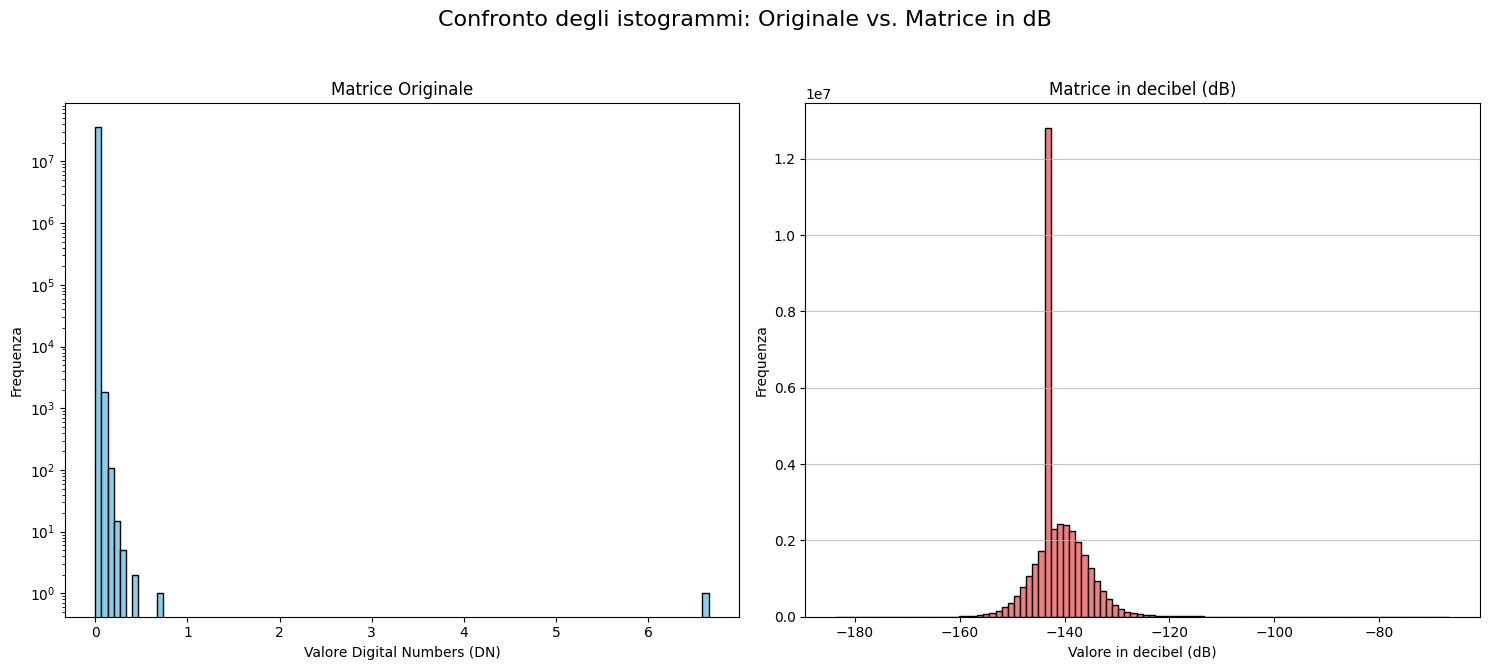

In [6]:
import matplotlib.pyplot as plt

fig_compare_hists, axes_compare_hists = plt.subplots(1, 2, figsize=(15, 7))
fig_compare_hists.suptitle('Confronto degli istogrammi: Originale vs. Matrice in dB', fontsize=16)

# Istogramma della matrice_dn (Originale)
axes_compare_hists[0].hist(matrice_dn.flatten(), bins=100, color='skyblue', edgecolor='black')
axes_compare_hists[0].set_title('Matrice Originale')
axes_compare_hists[0].set_xlabel('Valore Digital Numbers (DN)')
axes_compare_hists[0].set_ylabel('Frequenza')
axes_compare_hists[0].set_yscale('log')

# Istogramma di matrice in decibel (dB)
axes_compare_hists[1].hist(matrice_db.flatten(), bins=100, color='lightcoral', edgecolor='black')
axes_compare_hists[1].set_title('Matrice in decibel (dB)')
axes_compare_hists[1].set_xlabel('Valore in decibel (dB)')
axes_compare_hists[1].set_ylabel('Frequenza')
axes_compare_hists[0].set_yscale('log')

# Visualizzazione
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.grid(axis='y', alpha=0.75)
plt.show()

**Riduzione del rumore**

Le immagini ottenute dai radar sono intrinsecamente affette da un tipo specifico di rumore chiamato speckle, che appare come un effetto 'sale e pepe'. Questo rumore può oscurare i dettagli importanti e rendere difficile l'identificazione di caratteristiche.

L'obiettivo principale del de-noising è quello di pulire l'immagine applicando filtri digitali (come quelli spaziali, mediani o bilaterali). In questo modo, si evita che gli algoritmi successivi confondano il rumore di fondo con veri frammenti di paleo-canali, migliorando l'accuratezza dell'identificazione.

In [7]:
import cv2
import numpy as np

# =====================================================================
# PASSAGGIO 2: DE-NOISING DELLA MATRICE DI RETRODIFFUSIONE
# =====================================================================
print("[2/6] Riduzione del rumore di speckle nella matrice logaritmica...")

# Opzione A: Filtro statistico spaziale deterministico basato sulla media locale (intorno 5x5)
immagine_spaziale = uniform_filter(matrice_db, size=5)

# Opzione B: Filtro Mediano (Risolve il rumore senza sfocare i bordi)
immagine_mediana = cv2.medianBlur(matrice_db, 5)

# Opzione C: Filtro Bilaterale (Massima protezione dei contorni dei canali)
# Parametri: diametro intorno (5), sigmaColor (colore), sigmaSpace (spazio)
immagine_bilaterale = cv2.bilateralFilter(
    matrice_db, d=5, sigmaColor=75, sigmaSpace=75
)


[2/6] Riduzione del rumore di speckle nella matrice logaritmica...


Vengono create tre differenti immagini filtrate con obiettivo di verificare quale filtro rimuove il meglio il rumore di fondo dell'immagine

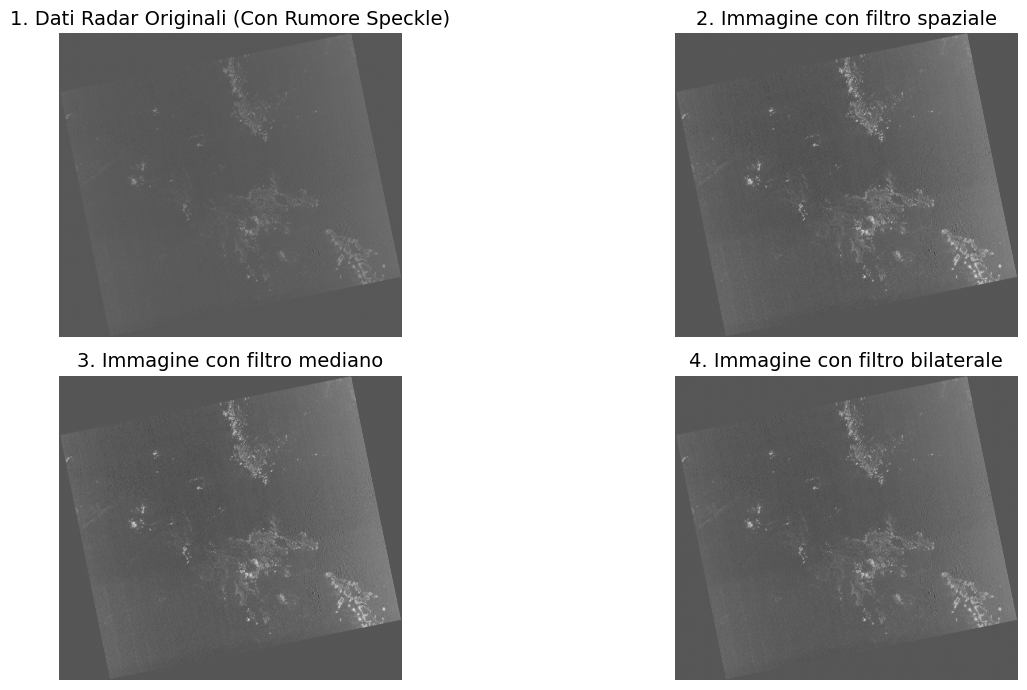

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 7))

# Grafico 1: Immagine Radar originale (con rumore speckle)
axes[0,0].imshow(matrice_db, cmap="gray")
axes[0,0].set_title("1. Dati Radar Originali (Con Rumore Speckle)", fontsize=14)
axes[0,0].axis("off")

# Grafico 2: Immagine Radar dopo il filtro media 5x5
axes[0,1].imshow(immagine_spaziale, cmap="gray")
axes[0,1].set_title(
    "2. Immagine con filtro spaziale", fontsize=14
)
axes[0,1].axis("off")

# Grafico 3: Immagine Radar dopo il filtro mediano: risolve il rumore senza sfocare i bordi
axes[1,0].imshow(immagine_mediana, cmap="gray")
axes[1,0].set_title(
    "3. Immagine con filtro mediano", fontsize=14
)
axes[1,0].axis("off")

# Grafico 4: Immagine Radar dopo il filtro bilaterale: massima protezione dei contorni dei canali
axes[1,1].imshow(immagine_bilaterale, cmap="gray")
axes[1,1].set_title(
    "4. Immagine con filtro bilaterale", fontsize=14
)
axes[1,1].axis("off")

plt.tight_layout()
plt.show()


Ad una prima osservazione, non si riscontrano particolari differenze fra le immagini filtrate. Non si comprende quindi quale filtro potrebbe essere il migliore, si esplorano altre metriche per verificare la soluzione migliore

**Confronto degli Istogrammi: Dati Originali vs. Filtri**

Per analizzare l'effetto dei diversi filtri sul rumore speckle e sulla distribuzione dei valori, possiamo confrontare gli istogrammi delle matrici otenute dopo l'applicazione del filtro

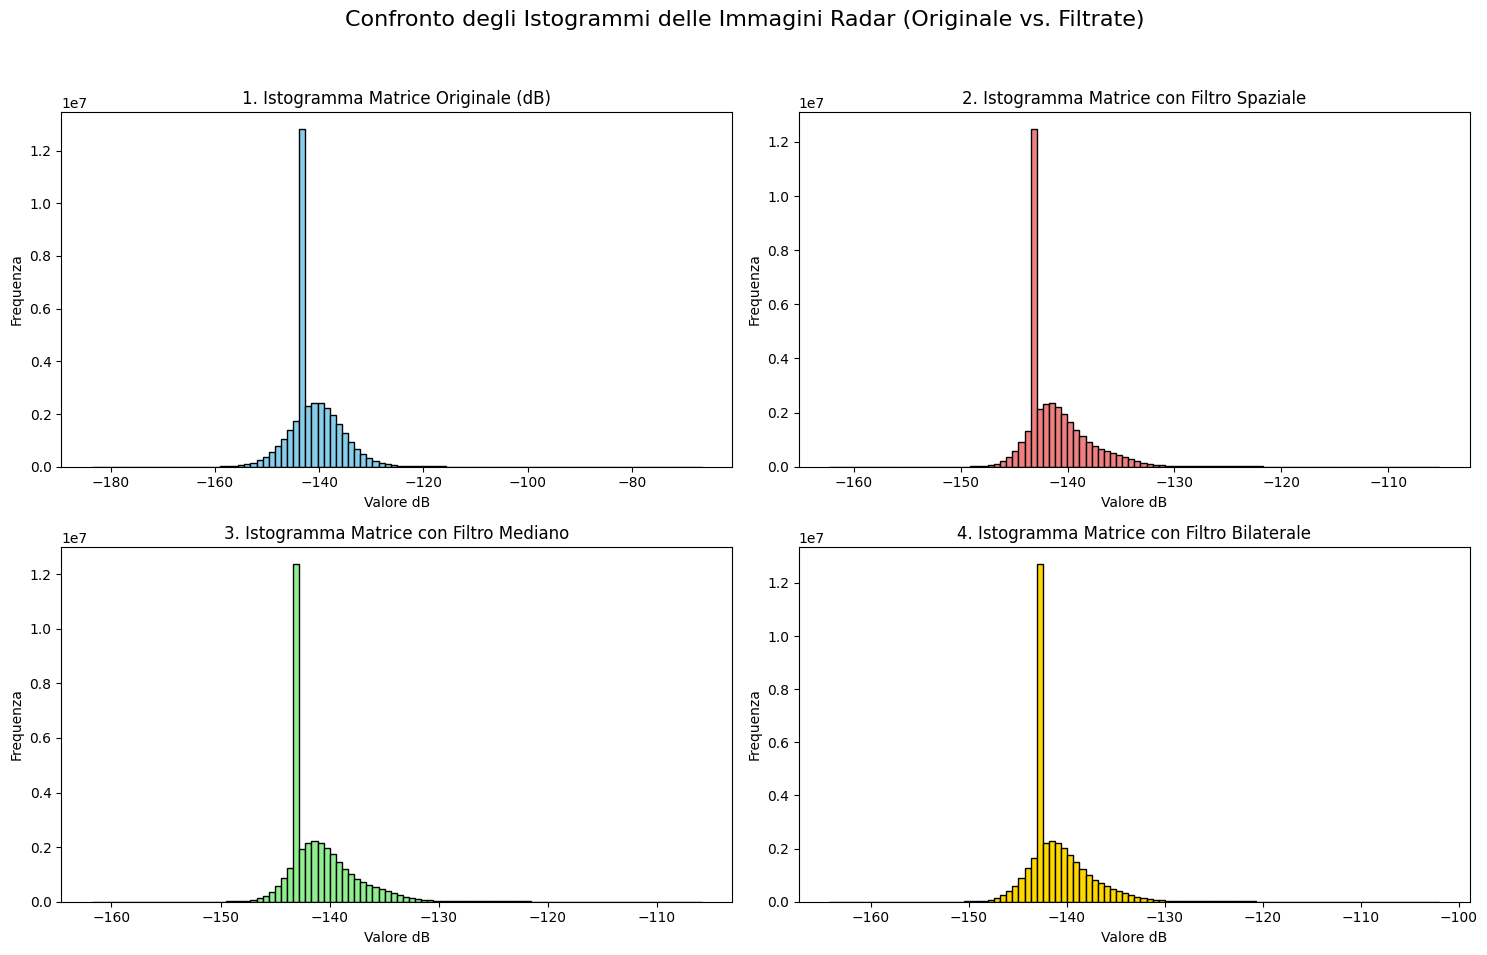

In [9]:
import matplotlib.pyplot as plt

fig_hist, axes_hist = plt.subplots(2, 2, figsize=(15, 10))
fig_hist.suptitle('Confronto degli Istogrammi delle Immagini Radar (Originale vs. Filtrate)', fontsize=16)

# Istogramma di matrice_db (Originale)
axes_hist[0, 0].hist(matrice_db.flatten(), bins=100, color='skyblue', edgecolor='black')
axes_hist[0, 0].set_title('1. Istogramma Matrice Originale (dB)')
axes_hist[0, 0].set_xlabel('Valore dB')
axes_hist[0, 0].set_ylabel('Frequenza')

# Istogramma di matrice_filtrata (Filtro Spaziale Media)
axes_hist[0, 1].hist(immagine_spaziale.flatten(), bins=100, color='lightcoral', edgecolor='black')
axes_hist[0, 1].set_title('2. Istogramma Matrice con Filtro Spaziale')
axes_hist[0, 1].set_xlabel('Valore dB')
axes_hist[0, 1].set_ylabel('Frequenza')

# Istogramma di immagine_mediana (Filtro Mediano)
axes_hist[1, 0].hist(immagine_mediana.flatten(), bins=100, color='lightgreen', edgecolor='black')
axes_hist[1, 0].set_title('3. Istogramma Matrice con Filtro Mediano')
axes_hist[1, 0].set_xlabel('Valore dB')
axes_hist[1, 0].set_ylabel('Frequenza')

# Istogramma di immagine_bilaterale (Filtro Bilaterale)
axes_hist[1, 1].hist(immagine_bilaterale.flatten(), bins=100, color='gold', edgecolor='black')
axes_hist[1, 1].set_title('4. Istogramma Matrice con Filtro Bilaterale')
axes_hist[1, 1].set_xlabel('Valore dB')
axes_hist[1, 1].set_ylabel('Frequenza')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Aggiusta il layout per evitare sovrapposizioni, lasciando spazio per il titolo generale
plt.show()

Anche con questo metodo di confronto non emergono differenze significative

**Visualizzazione delle Immagini di Differenza**

Per un'analisi più dettagliata dell'impatto di ciascun filtro, calcoliamo le immagini di differenza. Ogni immagine di differenza rappresenta il valore assoluto della sottrazione tra l'immagine originale in dB e la rispettiva immagine filtrata. Questo permette di isolare e visualizzare i cambiamenti apportati dal filtro.

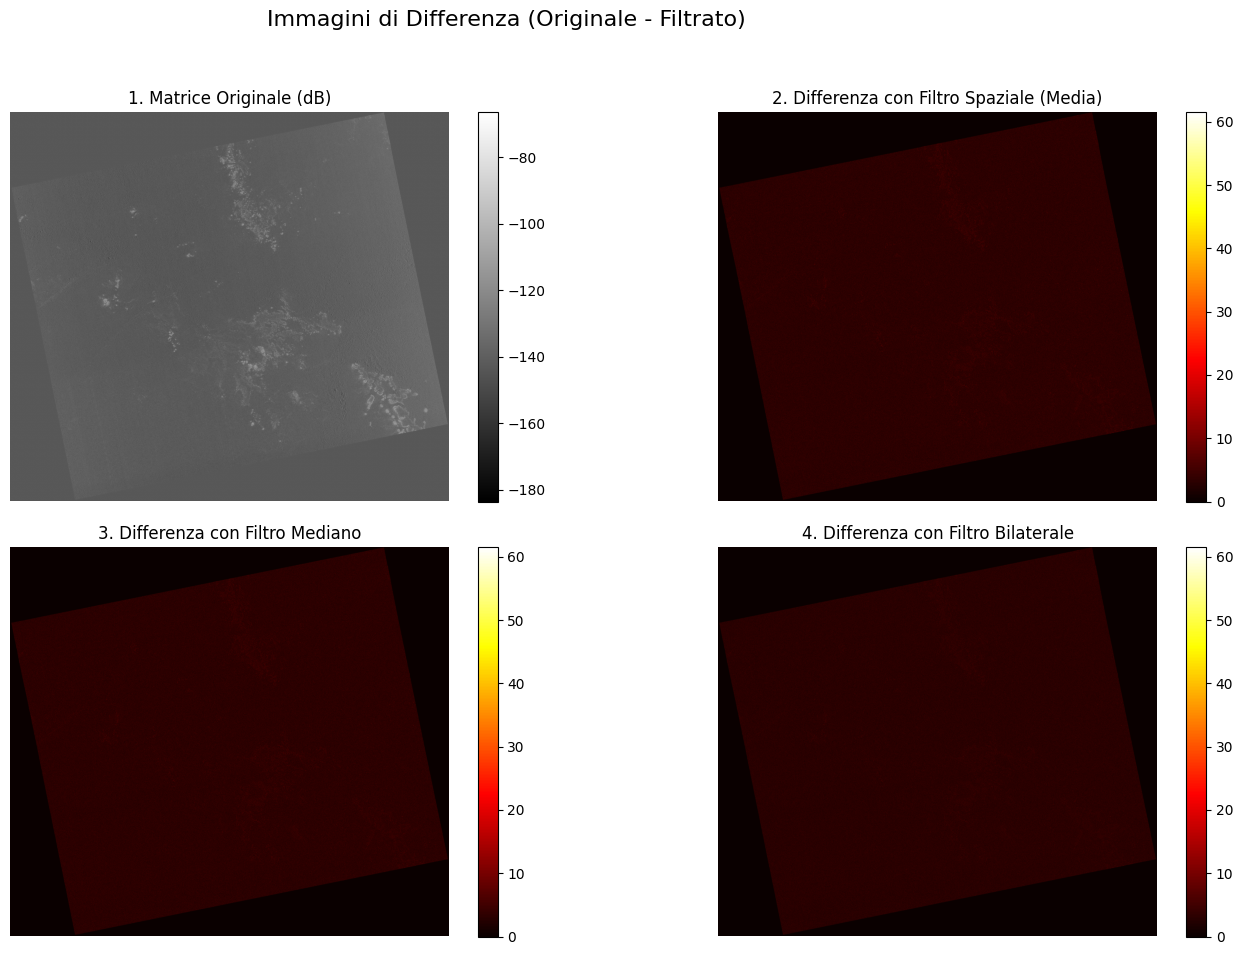

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calcola le immagini di differenza (valore assoluto)
diff_media = np.abs(matrice_db - immagine_spaziale)
diff_mediana = np.abs(matrice_db - immagine_mediana)
diff_bilaterale = np.abs(matrice_db - immagine_bilaterale)

# Crea una figura con 4 subplot per visualizzare le differenze
fig_diff, axes_diff = plt.subplots(2, 2, figsize=(15, 10))
fig_diff.suptitle('Immagini di Differenza (Originale - Filtrato)', fontsize=16)

# Range di visualizzazione comune per le immagini di differenza per un confronto migliore
# Impostiamo vmin e vmax in base al range comune (o massimo) delle differenze
vmax_common = max(diff_media.max(), diff_mediana.max(), diff_bilaterale.max())
vmin_common = min(diff_media.min(), diff_mediana.min(), diff_bilaterale.min())

# Plot Immagine Originale (per riferimento)
img_orig = axes_diff[0, 0].imshow(matrice_db, cmap='gray', vmin=matrice_db.min(), vmax=matrice_db.max())
axes_diff[0, 0].set_title('1. Matrice Originale (dB)')
axes_diff[0, 0].axis('off')
fig_diff.colorbar(img_orig, ax=axes_diff[0, 0], fraction=0.046, pad=0.04)


# Plot Differenza con Filtro Spaziale
img_diff_media = axes_diff[0, 1].imshow(diff_media, cmap='hot', vmin=vmin_common, vmax=vmax_common)
axes_diff[0, 1].set_title('2. Differenza con Filtro Spaziale (Media)')
axes_diff[0, 1].axis('off')
fig_diff.colorbar(img_diff_media, ax=axes_diff[0, 1], fraction=0.046, pad=0.04)

# Plot Differenza con Filtro Mediano
img_diff_mediana = axes_diff[1, 0].imshow(diff_mediana, cmap='hot', vmin=vmin_common, vmax=vmax_common)
axes_diff[1, 0].set_title('3. Differenza con Filtro Mediano')
axes_diff[1, 0].axis('off')
fig_diff.colorbar(img_diff_mediana, ax=axes_diff[1, 0], fraction=0.046, pad=0.04)

# Plot Differenza con Filtro Bilaterale
img_diff_bilaterale = axes_diff[1, 1].imshow(diff_bilaterale, cmap='hot', vmin=vmin_common, vmax=vmax_common)
axes_diff[1, 1].set_title('4. Differenza con Filtro Bilaterale')
axes_diff[1, 1].axis('off')
fig_diff.colorbar(img_diff_bilaterale, ax=axes_diff[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Aggiusta il layout
plt.show()

Anche con questo metodo di confronto non emergono differenze significative

**Calcolo delle Metriche di Qualità: PSNR e SSIM**

Non avendo ottenuto informazioni significative che ci permettono di sceglie quale filtro utilizzare utilizziamo delle metriche quantitative come PSNR (Peak Signal-to-Noise Ratio) e SSIM (Structural Similarity Index Measure). Tali metriche infatti, possono fornire una valutazione numerica dell'efficacia dei filtri di denoising. Valori più alti delle metriche indicano una maggiore similarità con l'immagine originale e, nel contesto del denoising, un minor deterioramento del segnale utile.

In [11]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Definisco il data_range basandoti sull'immagine originale
data_range_db = matrice_db.max() - matrice_db.min()

print(f"Range dei dati per il calcolo delle metriche: {data_range_db:.2f}\n")

# --- Calcolo PSNR ---
psnr_media = peak_signal_noise_ratio(matrice_db, immagine_spaziale, data_range=data_range_db)
psnr_mediana = peak_signal_noise_ratio(matrice_db, immagine_mediana, data_range=data_range_db)
psnr_bilaterale = peak_signal_noise_ratio(matrice_db, immagine_bilaterale, data_range=data_range_db)

print("--- PSNR ---")
print(f"PSNR (Filtro Spaziale Media): {psnr_media:.2f} dB")
print(f"PSNR (Filtro Mediano): {psnr_mediana:.2f} dB")
print(f"PSNR (Filtro Bilaterale): {psnr_bilaterale:.2f} dB\n")

# --- Calcolo SSIM ---
ssim_media = structural_similarity(matrice_db, immagine_spaziale, data_range=data_range_db)
ssim_mediana = structural_similarity(matrice_db, immagine_mediana, data_range=data_range_db)
ssim_bilaterale = structural_similarity(matrice_db, immagine_bilaterale, data_range=data_range_db)

print("--- SSIM ---")
print(f"SSIM (Filtro Spaziale Media): {ssim_media:.4f}")
print(f"SSIM (Filtro Mediano): {ssim_mediana:.4f}")
print(f"SSIM (Filtro Bilaterale): {ssim_bilaterale:.4f}")


Range dei dati per il calcolo delle metriche: 117.07

--- PSNR ---
PSNR (Filtro Spaziale Media): 30.59 dB
PSNR (Filtro Mediano): 30.51 dB
PSNR (Filtro Bilaterale): 31.27 dB

--- SSIM ---
SSIM (Filtro Spaziale Media): 0.6431
SSIM (Filtro Mediano): 0.6416
SSIM (Filtro Bilaterale): 0.7017


Visualizzo graficamente le metriche calcolate

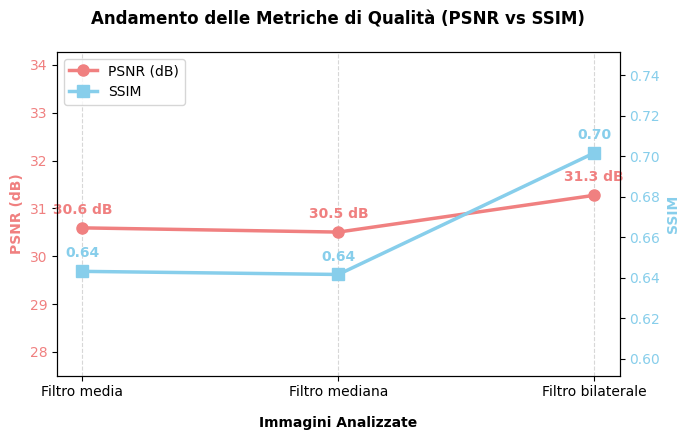

In [12]:
import matplotlib.pyplot as plt

# 1. Definizione dei dati per le 3 immagini
immagini = ['Filtro media', 'Filtro mediana', 'Filtro bilaterale']
valori_psnr = [psnr_media, psnr_mediana, psnr_bilaterale]
valori_ssim = [ssim_media, ssim_mediana, ssim_bilaterale]  # Scala 0-1 (Asse Destro)

# 2. Configurazione della figura e del primo asse Y (PSNR - Sinistra)
fig, ax1 = plt.subplots(figsize=(7, 4.5))

color_psnr = 'lightcoral'
ax1.set_xlabel('Immagini Analizzate', fontweight='bold', labelpad=12)
ax1.set_ylabel('PSNR (dB)', color=color_psnr, fontweight='bold')

# Grafico a linee per il PSNR
linea1 = ax1.plot(immagini, valori_psnr, color=color_psnr, marker='o', linewidth=2.5, markersize=8, label='PSNR (dB)')
ax1.tick_params(axis='y', labelcolor=color_psnr)

# Aggiunta dei valori numerici sopra i punti del PSNR
for i, txt in enumerate(valori_psnr):
    ax1.annotate(f'{txt:.1f} dB', (immagini[i], valori_psnr[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=color_psnr)

# Imposta i limiti verticali lasciando margine per i testi
ax1.set_ylim(min(valori_psnr) - 3, max(valori_psnr) + 3)

# 3. Configurazione del secondo asse Y (SSIM - Destra)
ax2 = ax1.twinx()

color_ssim = 'skyblue'
ax2.set_ylabel('SSIM', color=color_ssim, fontweight='bold')

# Grafico a linee per lo SSIM
linea2 = ax2.plot(immagini, valori_ssim, color=color_ssim, marker='s', linewidth=2.5, markersize=8, label='SSIM')
ax2.tick_params(axis='y', labelcolor=color_ssim)

# Aggiunta dei valori numerici sopra i punti dello SSIM
for i, txt in enumerate(valori_ssim):
    ax2.annotate(f'{txt:.2f}', (immagini[i], valori_ssim[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=color_ssim)

# Imposta i limiti verticali dello SSIM (scala standard 0-1 con margine)
ax2.set_ylim(min(valori_ssim) - 0.05, max(valori_ssim) + 0.05)

# 4. Personalizzazione estetica (Titolo, Griglia e Legenda)
plt.title('Andamento delle Metriche di Qualità (PSNR vs SSIM)', fontsize=12, fontweight='bold', pad=20)

# Unione delle legende dei due assi in un unico box
linee = linea1 + linea2
etichette = [l.get_label() for l in linee]
ax1.legend(linee, etichette, loc='upper left')

# Aggiunge una griglia leggera di sfondo solo sull'asse X per allineare i punti
ax1.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Interpretazione delle Metriche PSNR e SSIM**

**1. PSNR (Peak Signal-to-Noise Ratio):** il PSNR misura il rapporto tra la potenza massima di un segnale e la potenza del rumore di disturbo che influisce sulla sua fedeltà. È espresso in decibel (dB).
Valori più alti (in dB) indicano una migliore qualità dell'immagine e una minore quantità di rumore residuo. Un aumento di PSNR significa che la differenza quadratica media tra l'immagine originale e quella filtrata è diminuita, suggerendo che il filtro ha rimosso rumore senza alterare significativamente il segnale originale.

**2. SSIM (Structural Similarity Index Measure):** l'SSIM è una metrica più sofisticata che cerca di quantificare la percezione umana della somiglianza tra due immagini. Non si basa solo sulle differenze di pixel, ma considera anche la somiglianza di *luminanza, contrasto e struttura*. I valori SSIM variano tipicamente tra -1 e 1. Un valore più vicino a 1 indica una maggiore somiglianza strutturale tra l'immagine originale e quella filtrata. Valori più alti indicano che il filtro ha preservato meglio la struttura complessiva dell'immagine (bordi, pattern, ecc.) mentre rimuoveva il rumore.

L'immagine con filtro bilaterale risulta la migliore in quanto i *SSIM* e *PSNR* risultano maggiori rispetto alle altre opzioni considerate

In [13]:
# Seleziono la matrice con filtro bilaterale
matrice_selezionata = immagine_bilaterale


**Miglioramento del contrasto matriciale:**

Spesso la differenza di segnale tra il potenziale che identifica il paleo-canale e il deserto circostante è minima. Applicando tecniche di miglioramento del contrasto riusciamo a "*dilatare*" le sfumature di grigio. Questo rende i bordi delle strutture sepolte molto più netti e distinguibili, sia per l'occhio umano che per gli algoritmi.


[3/6] Stretching lineare dell'intervallo numerico di retrodiffusione...


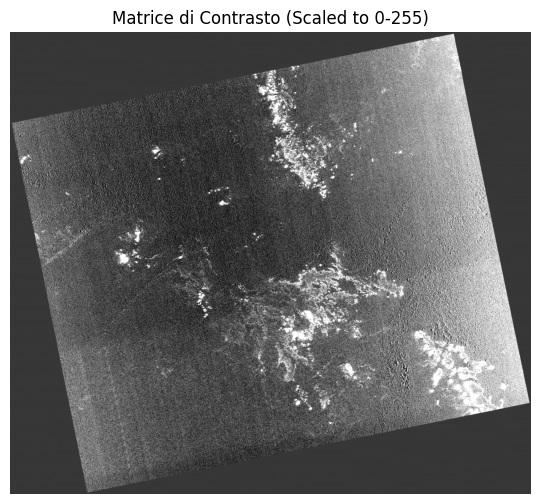

In [14]:
import matplotlib.pyplot as plt

# =====================================================================
# PASSAGGIO 3: MIGLIORAMENTO DEL CONTRASTO MATRICIALE (Contrast Stretching)
# =====================================================================
print("[3/6] Stretching lineare dell'intervallo numerico di retrodiffusione...")

# Individuazione dei limiti numerici utili escludendo le anomalie (2° e 98° percentile)
valore_min_db, valore_max_db = np.percentile(matrice_selezionata, (2, 98))

# Limitazione dei valori entro l'intervallo matematico calcolato
matrice_troncata = np.clip(matrice_selezionata, valore_min_db, valore_max_db)

# Espansione lineare dei valori per massimizzare la separazione numerica (range 0.0 - 1.0)
matrice_contrasto = (matrice_troncata - valore_min_db) / (
    valore_max_db - valore_min_db
)

# Scale the contrast matrix (which is 0-1) to 0-255
matrice_contrasto_uint8 = (matrice_contrasto * 255).astype(np.uint8)

# Display the image using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(matrice_contrasto_uint8, cmap='gray')
plt.title('Matrice di Contrasto (Scaled to 0-255)')
plt.axis('off')
plt.show()


**Altri Metodi per il Miglioramento del Contrasto Matriciale**

Il *contrast stretching* lineare applicato è un metodo efficace, ma esistono altre tecniche, più o meno sofisticate, che possono offrire risultati migliori a seconda delle caratteristiche dell'immagine e degli obiettivi dell'analisi:

1.  **Equalizzazione dell'Istogramma (Histogram Equalization)**: Ridistribuisce l'intensità dei pixel in modo da occupare l'intera gamma dinamica disponibile in modo uniforme. Tenta di rendere l'istogramma dell'immagine il più piatto possibile.

2.  **Equalizzazione Adattiva dell'Istogramma (Adaptive Histogram Equalization - AHE/CLAHE)**: Invece di applicare l'equalizzazione all'intera immagine, l'immagine viene divisa in piccole regioni (tiles). Per ogni regione, viene calcolata ed applicata un'equalizzazione dell'istogramma separata. La versione CLAHE (Contrast Limited Adaptive Histogram Equalization) limita l'amplificazione del contrasto per ridurre il rumore.

3.  **Correzione Gamma (Gamma Correction)**: Applica una trasformazione non lineare ai valori di intensità dei pixel, spesso per correggere problemi di luminosità o per alterare la curva tonale dell'immagine.

Nel caso in esame, il contrasto matriciale con **CLAHE** potrebbe fornire un risultato interessante, poiché i paleo-canali potrebbero avere un contrasto locale sottile che un metodo globale potrebbe non evidenziare.

Applicazione di Equalizzazione Adattiva dell'Istogramma (CLAHE)...
Matrice CLAHE salvata in: /content/drive/MyDrive/Homework_Big_data/dataset/AP_19252_FBD_F0440_RT1/AP_19252_FBD_F0440_RT1/matrice_clahe.jpg


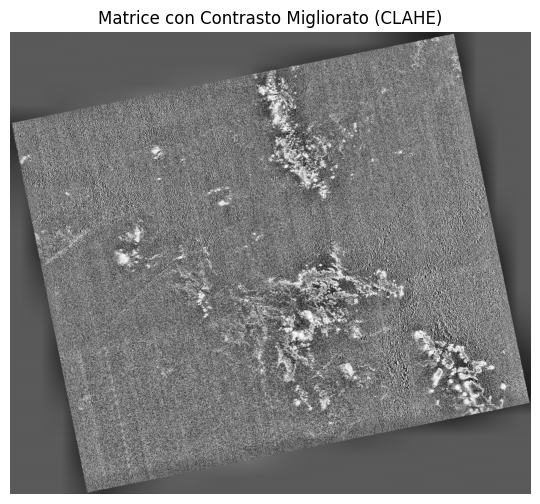

In [15]:
from skimage import exposure
import matplotlib.pyplot as plt

# =====================================================================
# PASSO 3 ALTERNATIVO: MIGLIORAMENTO DEL CONTRASTO CON CLAHE
# =====================================================================
print("Applicazione di Equalizzazione Adattiva dell'Istogramma (CLAHE)...")

# Normalizzazione della matrice_selezionata a un range 0-1 per CLAHE
# CLAHE funziona meglio su immagini con valori normalizzati.
matrice_normalizzata = (matrice_selezionata - matrice_selezionata.min()) / \
                       (matrice_selezionata.max() - matrice_selezionata.min())

# Applica CLAHE. I parametri clip_limit e kernel_size sono importanti per i risultati.
# clip_limit: limita l'amplificazione del contrasto. Valori comuni 0.01 - 0.03
# kernel_size: dimensione della regione su cui viene calcolato l'istogramma localmente.
matrice_clahe = exposure.equalize_adapthist(
    matrice_normalizzata,
    clip_limit=0.03,
    kernel_size=(256, 256)
)

# Converti la matrice CLAHE in uint8 (0-255) per la visualizzazione/salvataggio
matrice_clahe_uint8 = (matrice_clahe * 255).astype(np.uint8)

# Salvataggio della matrice CLAHE come JPEG
OUTPUT_CLAHE_JPEG = path + "matrice_clahe.jpg"
img_clahe = Image.fromarray(matrice_clahe_uint8)
img_clahe.save(OUTPUT_CLAHE_JPEG)

print(f"Matrice CLAHE salvata in: {OUTPUT_CLAHE_JPEG}")

# Visualizzazione della matrice CLAHE
plt.figure(figsize=(8, 6))
plt.imshow(matrice_clahe_uint8, cmap='gray')
plt.title('Matrice con Contrasto Migliorato (CLAHE)')
plt.axis('off')
plt.show()


In analogia con le analisi precedenti, viene eseguito un confronto diretto tra le soluzioni ottenute, prendendo in esame sia la qualità visiva delle immagini sia i rispettivi profili istogrammici.

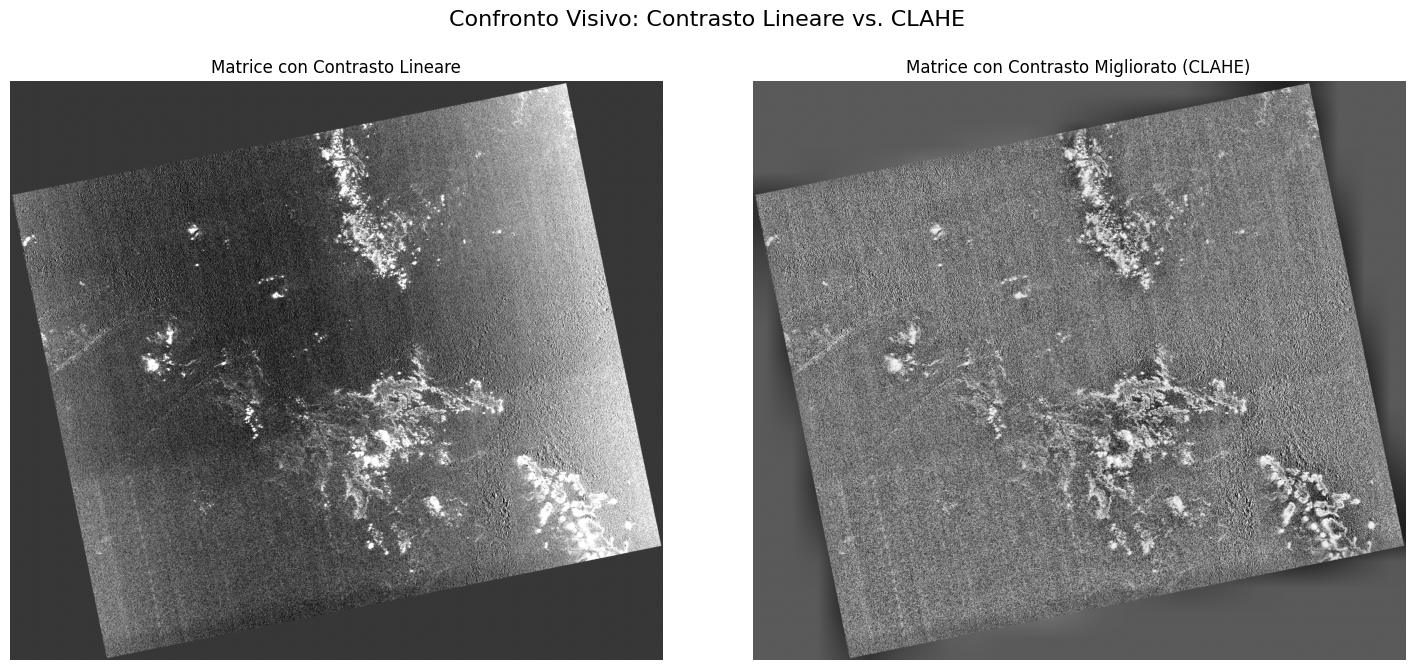

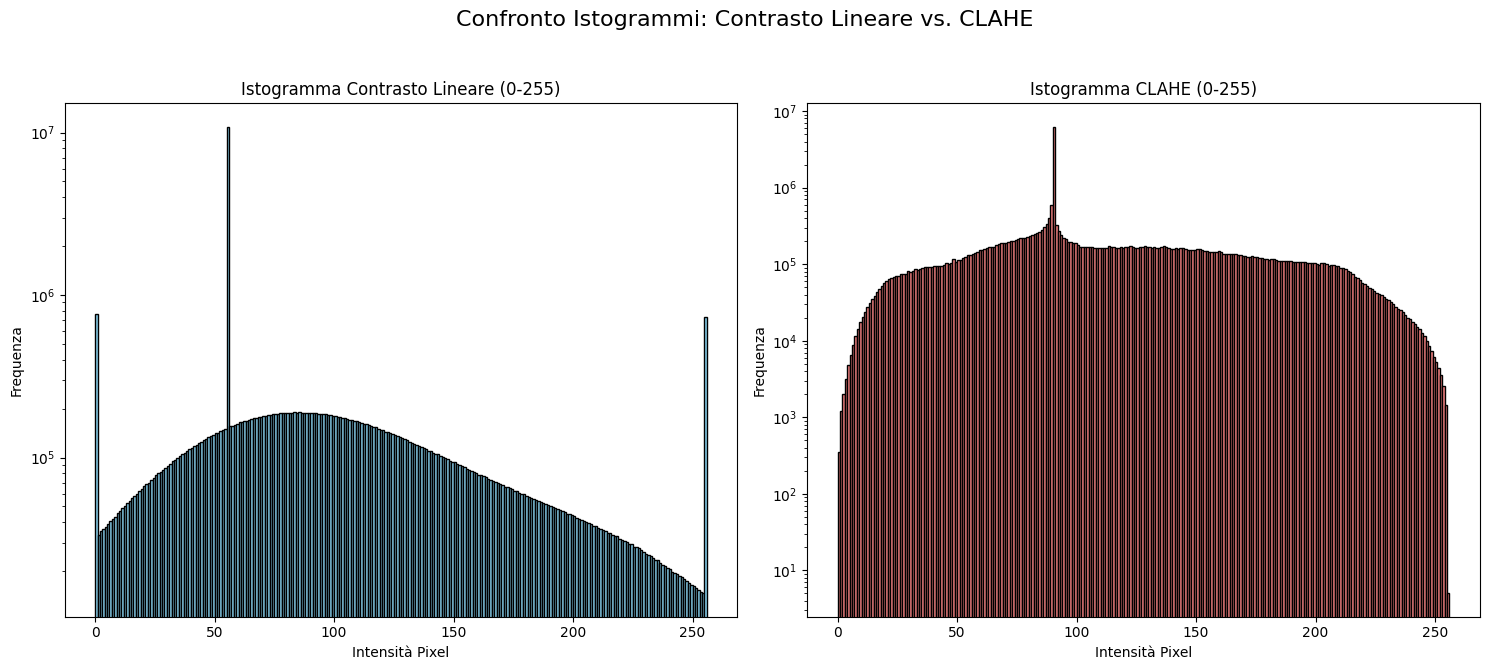

In [16]:
import matplotlib.pyplot as plt

# --- Visualizzazione delle Immagini a Confronto ---
fig_images, axes_images = plt.subplots(1, 2, figsize=(15, 7))
fig_images.suptitle('Confronto Visivo: Contrasto Lineare vs. CLAHE', fontsize=16)

# Immagine con Contrasto Lineare
axes_images[0].imshow(matrice_contrasto_uint8, cmap='gray')
axes_images[0].set_title('Matrice con Contrasto Lineare')
axes_images[0].axis('off')

# Immagine con CLAHE
axes_images[1].imshow(matrice_clahe_uint8, cmap='gray')
axes_images[1].set_title('Matrice con Contrasto Migliorato (CLAHE)')
axes_images[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Visualizzazione degli Istogrammi a Confronto ---
fig_hists, axes_hists = plt.subplots(1, 2, figsize=(15, 7))
fig_hists.suptitle('Confronto Istogrammi: Contrasto Lineare vs. CLAHE', fontsize=16)

# Istogramma della Matrice con Contrasto Lineare
axes_hists[0].hist(matrice_contrasto_uint8.flatten(), bins=256, range=(0, 256), color='skyblue', edgecolor='black')
axes_hists[0].set_title('Istogramma Contrasto Lineare (0-255)')
axes_hists[0].set_xlabel('Intensità Pixel')
axes_hists[0].set_ylabel('Frequenza')
axes_hists[0].set_yscale('log') # Utile se la distribuzione è molto sbilanciata

# Istogramma della Matrice con CLAHE
axes_hists[1].hist(matrice_clahe_uint8.flatten(), bins=256, range=(0, 256), color='lightcoral', edgecolor='black')
axes_hists[1].set_title('Istogramma CLAHE (0-255)')
axes_hists[1].set_xlabel('Intensità Pixel')
axes_hists[1].set_ylabel('Frequenza')
axes_hists[1].set_yscale('log') # Utile se la distribuzione è molto sbilanciata

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Analisi degli Istogrammi:**

L'Istogramma del Contrasto Lineare (a sinistra) mostra che la maggior parte dei pixel è ancora concentrata intorno a un valore medio, con picchi ai bordi (0 e 255) a causa dell'operazione di np.clip e del stretching che forza i valori al minimo e massimo disponibili. Questo indica che, sebbene l'intervallo sia stato allungato, la distribuzione dei pixel non è diventata uniforme.
L'Istogramma CLAHE (a destra) appare molto più distribuito e tendenzialmente più piatto, soprattutto nella parte centrale. I picchi iniziali e finali sono meno pronunciati o assenti, indicando che i valori dei pixel sono stati ridistribuiti in modo più omogeneo su tutto l'intervallo 0-255. Questa distribuzione più uniforme è il segno distintivo dell'equalizzazione dell'istogramma e di CLAHE in particolare, che mira a massimizzare la visibilità dei dettagli su tutta la gamma tonale.

Per tali motivi la scelta migliore risulta essere l'utilizzo del CLAHE (Equalizzazione Adattiva dell'Istogramma)per individuare caratteristiche sottili come i paleo-canali, che richiedono un'ottima percezione del contrasto a livello locale. CLAHE risulta, nel caso specifico, superiore al semplice contrast stretching lineare in quanto massimizza la visibilità dei dettagli in ogni parte dell'immagine senza sacrificare la distribuzione complessiva dei pixel.

In [17]:
matrice_contrasto_selezionata= matrice_clahe_uint8

**Segmentazione numerica (Soglia di Otsu)**


Obiettivo principale è dividere l'immagine in due classi: le aree di 'interesse' (i potenziali paleo-canali, che hanno una retro-diffusione più elevata) e il 'background' (la sabbia o altre strutture, con retro-diffusione inferiore). Invece di scegliere manualmente una soglia, l'algoritmo di Otsu la calcola in modo ottimale la soglia discirminante che permette di classificare il pixel in esame.

L'algortimo analizza l'istogramma dei valori di intensità dell'immagine e trova il valore che minimizza la varianza all'interno delle due classi create ('foreground' e 'background') o che massimizza la varianza tra di esse.
Una volta trovata la soglia, tutti i pixel con valori superiori vengono assegnati a un valore (es. bianco o 1) e quelli inferiori a un altro (es. nero o 0), creando un'immagine in bianco e nero.

Si crea così una mappa semplificata dove le  sfumature di grigio sono state trasformate in un'informazione di 'presenza/assenza' dei paleo-canali.

[4/6] Calcolo della soglia di separazione statistica (Otsu)...


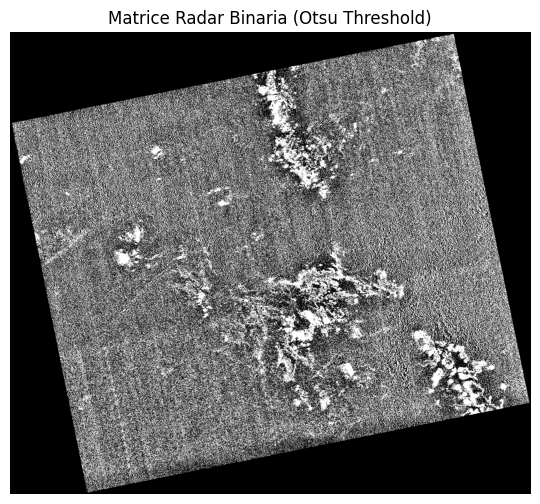

In [18]:
# =====================================================================
# PASSAGGIO 4: SEGMENTAZIONE NUMERICA (Soglia di Otsu)
# =====================================================================
print("[4/6] Calcolo della soglia di separazione statistica (Otsu)...")
# Calcolo rigoroso del punto di minimo dell'istogramma dei valori numerici
soglia_matematica = threshold_otsu(matrice_contrasto_selezionata)

# Generazione di una matrice booleana (0 e 1):
# 1 identifica i coefficienti ad alta retrodiffusione (potenziali canali sepolti)
matrice_radar_binaria = (matrice_contrasto_selezionata > soglia_matematica).astype(np.uint8)

# Scale the binary (0 or 1) uint8 array to 0 or 255 for better JPEG visualization
matrice_radar_binaria_scaled = (matrice_radar_binaria * 255).astype(np.uint8)

# Display the image using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(matrice_radar_binaria_scaled, cmap='gray')
plt.title('Matrice Radar Binaria (Otsu Threshold)')
plt.axis('off')
plt.show()



La matrice binaria risultante diventa l'input per il passaggio finale. Viene combinata con la matrice degli avvallamenti topografici per identificare solo le aree che soddisfano entrambi i criteri (alta retro-diffusione radar e avvallamento topografico), aumentando così l'affidabilità dell'individuazione.

[5/6] Analisi quantitativa della matrice delle altitudini (DEM)...


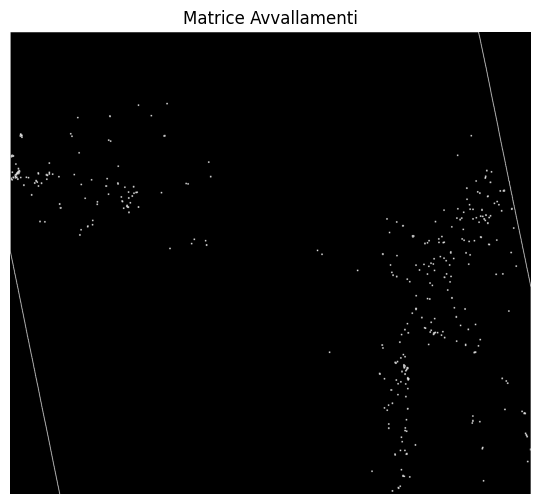

In [19]:
# =====================================================================
# PASSAGGIO 5: ANALISI DEI FLUSSI TOPOGRAFICI DEL TERRENO
# =====================================================================
print("[5/6] Analisi quantitativa della matrice delle altitudini (DEM)...")
with rasterio.open(path + DATASET_TOPOGRAFICO_DEM) as src_dem:
    matrice_altitudini = src_dem.read(1).astype(np.float32)

# Calcolo statistico degli avvallamenti del terreno (linee di flusso teoriche)
media_altitudine_locale = uniform_filter(matrice_altitudini, size=15)
matrice_avvallamenti = (matrice_altitudini < media_altitudine_locale).astype(
    np.uint8
)

# Scale the binary (0 or 1) uint8 array to 0 or 255 for better JPEG visualization
matrice_avvallamenti_scaled = (matrice_avvallamenti * 255).astype(np.uint8)

# Display the image using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(matrice_avvallamenti_scaled, cmap='gray')
plt.title('Matrice Avvallamenti')
plt.axis('off')
plt.show()


Sovrapposizione delle immagini

Numero di pixel attivi (valore 1) in matrice_radar_binaria: 12547506
Numero di pixel attivi (valore 1) in matrice_avvallamenti: 203383


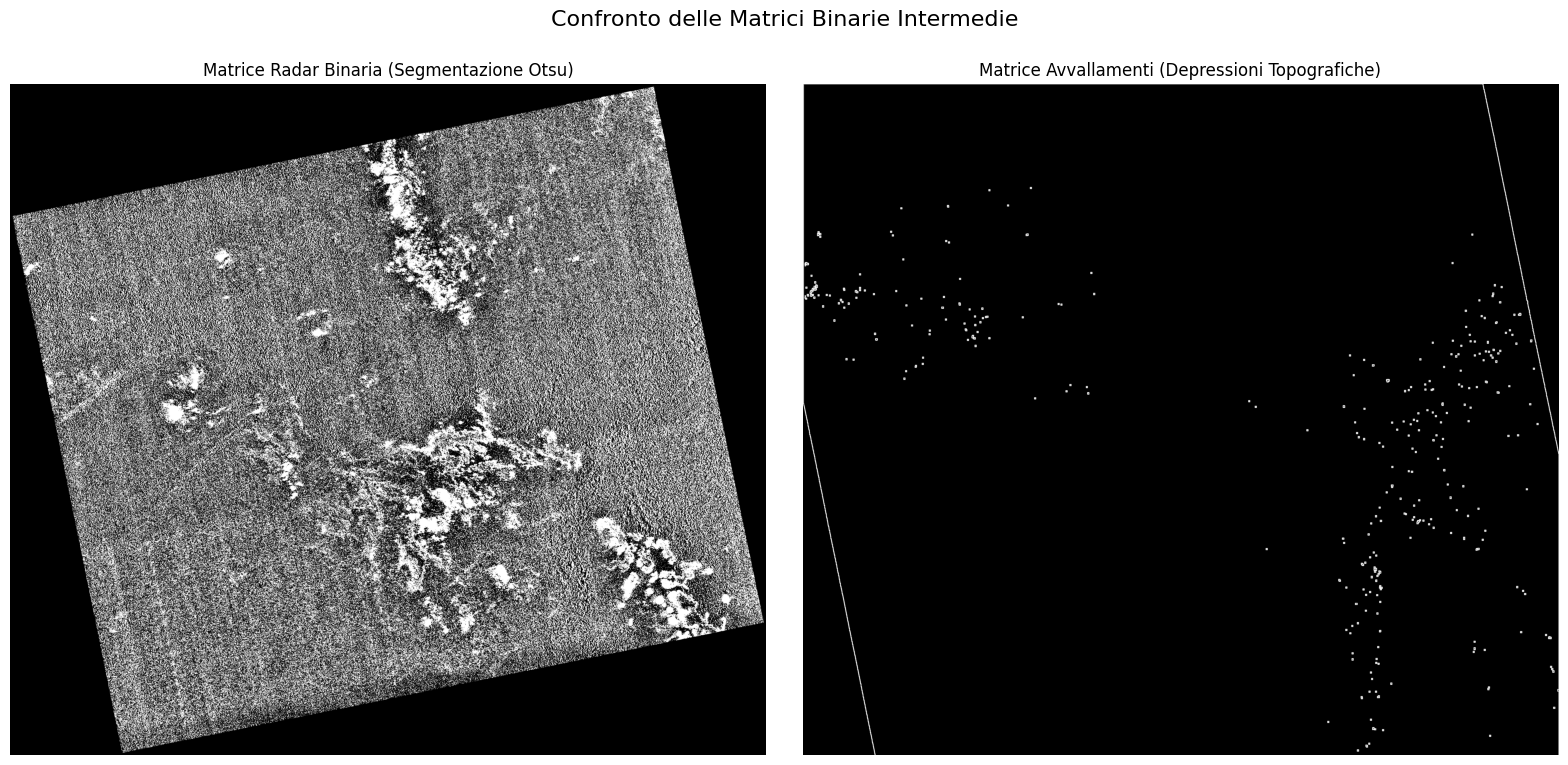

[6/6] Intersezione matematica dei criteri (Radar AND Topografia)...


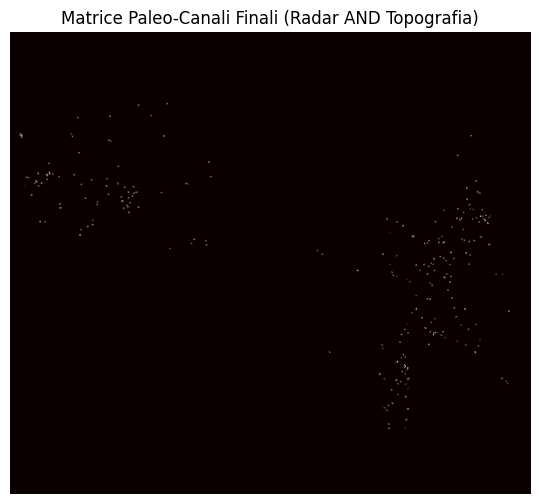

Numero di pixel attivi (valore 1) in matrice_paleo_canali_finali: 37305


In [20]:
import matplotlib.pyplot as plt

# =====================================================================
# PASSAGGIO 6: INTERSEZIONE LOGICA (AND) TRA MATRICI NUMERICHE
# =====================================================================

# --- Conteggio dei pixel attivi (valore 1) in ciascuna matrice ---
num_radar_active = np.sum(matrice_radar_binaria == 1)
num_avvallamenti_active = np.sum(matrice_avvallamenti == 1)

print(f"Numero di pixel attivi (valore 1) in matrice_radar_binaria: {num_radar_active}")
print(f"Numero di pixel attivi (valore 1) in matrice_avvallamenti: {num_avvallamenti_active}")

# --- Visualizzazione delle due matrici binarie a confronto ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Confronto delle Matrici Binarie Intermedie', fontsize=16)



# Visualizzazione matrice_radar_binaria
axes[0].imshow(matrice_radar_binaria, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Matrice Radar Binaria (Segmentazione Otsu)')
axes[0].axis('off')

# Visualizzazione matrice_avvallamenti
axes[1].imshow(matrice_avvallamenti, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Matrice Avvallamenti (Depressioni Topografiche)')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("[6/6] Intersezione matematica dei criteri (Radar AND Topografia)...")

# Estrazione finale: il pixel appartiene al paleo-canale se e solo se entrambi
# i criteri numerici delle rispettive matrici sono verificati (uguali a 1)
matrice_paleo_canali_finali = np.logical_and(
    matrice_radar_binaria == 1, matrice_avvallamenti == 1
).astype(np.uint8)

# Visualizzazione dell'intersezione logica per conferma
plt.figure(figsize=(8, 6))
plt.imshow(matrice_paleo_canali_finali, cmap='hot', vmin=0, vmax=1)
plt.title('Matrice Paleo-Canali Finali (Radar AND Topografia)')
plt.axis('off')

plt.show()

num_final_active = np.sum(matrice_paleo_canali_finali == 1)
print(f"Numero di pixel attivi (valore 1) in matrice_paleo_canali_finali: {num_final_active}")


**Implementazione dell'algoritmo Flood Fill**

L'algoritmo permette di determinare la regione connessa ad un dato punto (o "seme") in un'immagine multidimensionale. Partendo da un punto, l'algoritmo "riempie" tutti i pixel adiacenti che hanno un valore simile (o che soddisfano una certa condizione) fino a incontrare un "confine" (pixel con valori diversi).

Nel contesto dell'identificazione dei paleo-canali, l'applicazione del Flood Fill può essere utile per:

1.  Identificare componenti connesse: separare i singoli paleo-canali o segmenti di canali connessi. Se la matrice finale ha molte piccole macchie disconnesse, il Flood Fill può aiutare a raggrupparle in entità più grandi o a identificare le regioni significative.
2.  Rimuovere rumore o piccoli oggetti: potrebbero esserci piccole regioni isolate che non rappresentano veri paleo-canali. Applicando il Flood Fill e filtrando le regioni piccole, si può raffinare ulteriormente la segmentazione.

Applicazione dell'algoritmo Flood Fill per identificare le componenti connesse...
Trovate 788 componenti connesse nella matrice paleo-canali finali.


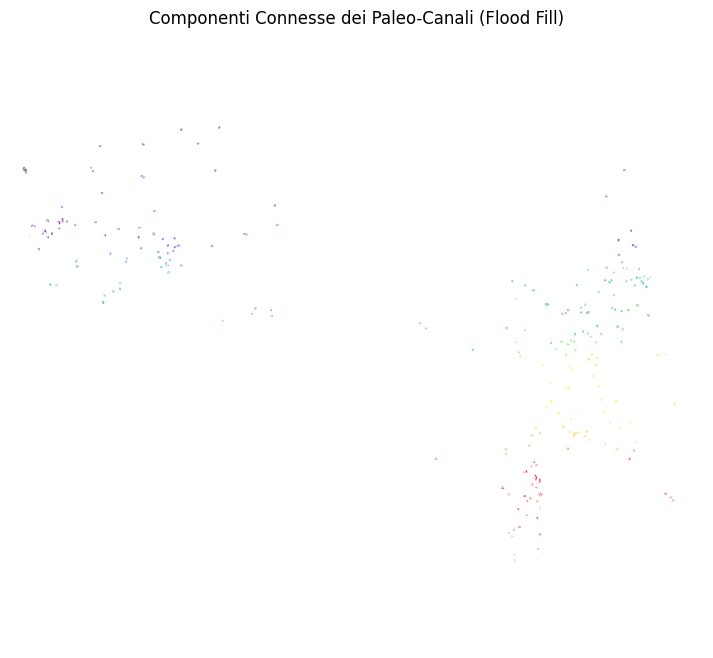

In [21]:
# =====================================================================
# PASSAGGIO 6: IMPLEMENTAZIONE DELL'ALGORITMO DI FLOOD FILL
# =====================================================================

from scipy.ndimage import label, generate_binary_structure
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("Applicazione dell'algoritmo Flood Fill per identificare le componenti connesse...")

# Definisci la struttura di connettività (8-connettività per adiacenza diagonale)
s = generate_binary_structure(2, 2) # 2 sta per 2D, 2 per 8-connettività

# Applica l'algoritmo label per trovare le componenti connesse
labeled_array, num_features = label(matrice_paleo_canali_finali, structure=s)

print(f"Trovate {num_features} componenti connesse nella matrice paleo-canali finali.")

# --- Visualizzazione delle componenti connesse ---
fig, ax = plt.subplots(figsize=(10, 8))

# Crea una colormap personalizzata per impostare il background a bianco
cmap = plt.get_cmap('nipy_spectral', num_features + 1)
colors = cmap(np.arange(cmap.N))
colors[0] = np.array([1, 1, 1, 1])  # Imposta il primo colore (corrispondente a 0) a bianco (RGBA)
new_cmap = mcolors.ListedColormap(colors)

# Usiamo la nuova colormap per distinguere le diverse componenti etichettate
ax.imshow(labeled_array, cmap=new_cmap, vmin=0, vmax=num_features)
ax.set_title('Componenti Connesse dei Paleo-Canali (Flood Fill)')
ax.axis('off')
plt.show()

I colori diversi nella visualizzazione sono utilizzati per distinguere visivamente le diverse componenti connesse che l'algoritmo Flood Fill ha identificato. Ogni colore diverso indica un segmento di paleo-canale distinto e separato dagli altri nella matrice.

**Visualizzazione dei paleo-canali su immagine Satellitare**

Per fornire un contesto reale, aggiungiamo un layer satellitare di Google Maps come sfondo alla mappa, sovrapponendo la matrice dei paleo-canali su questo sfondo.


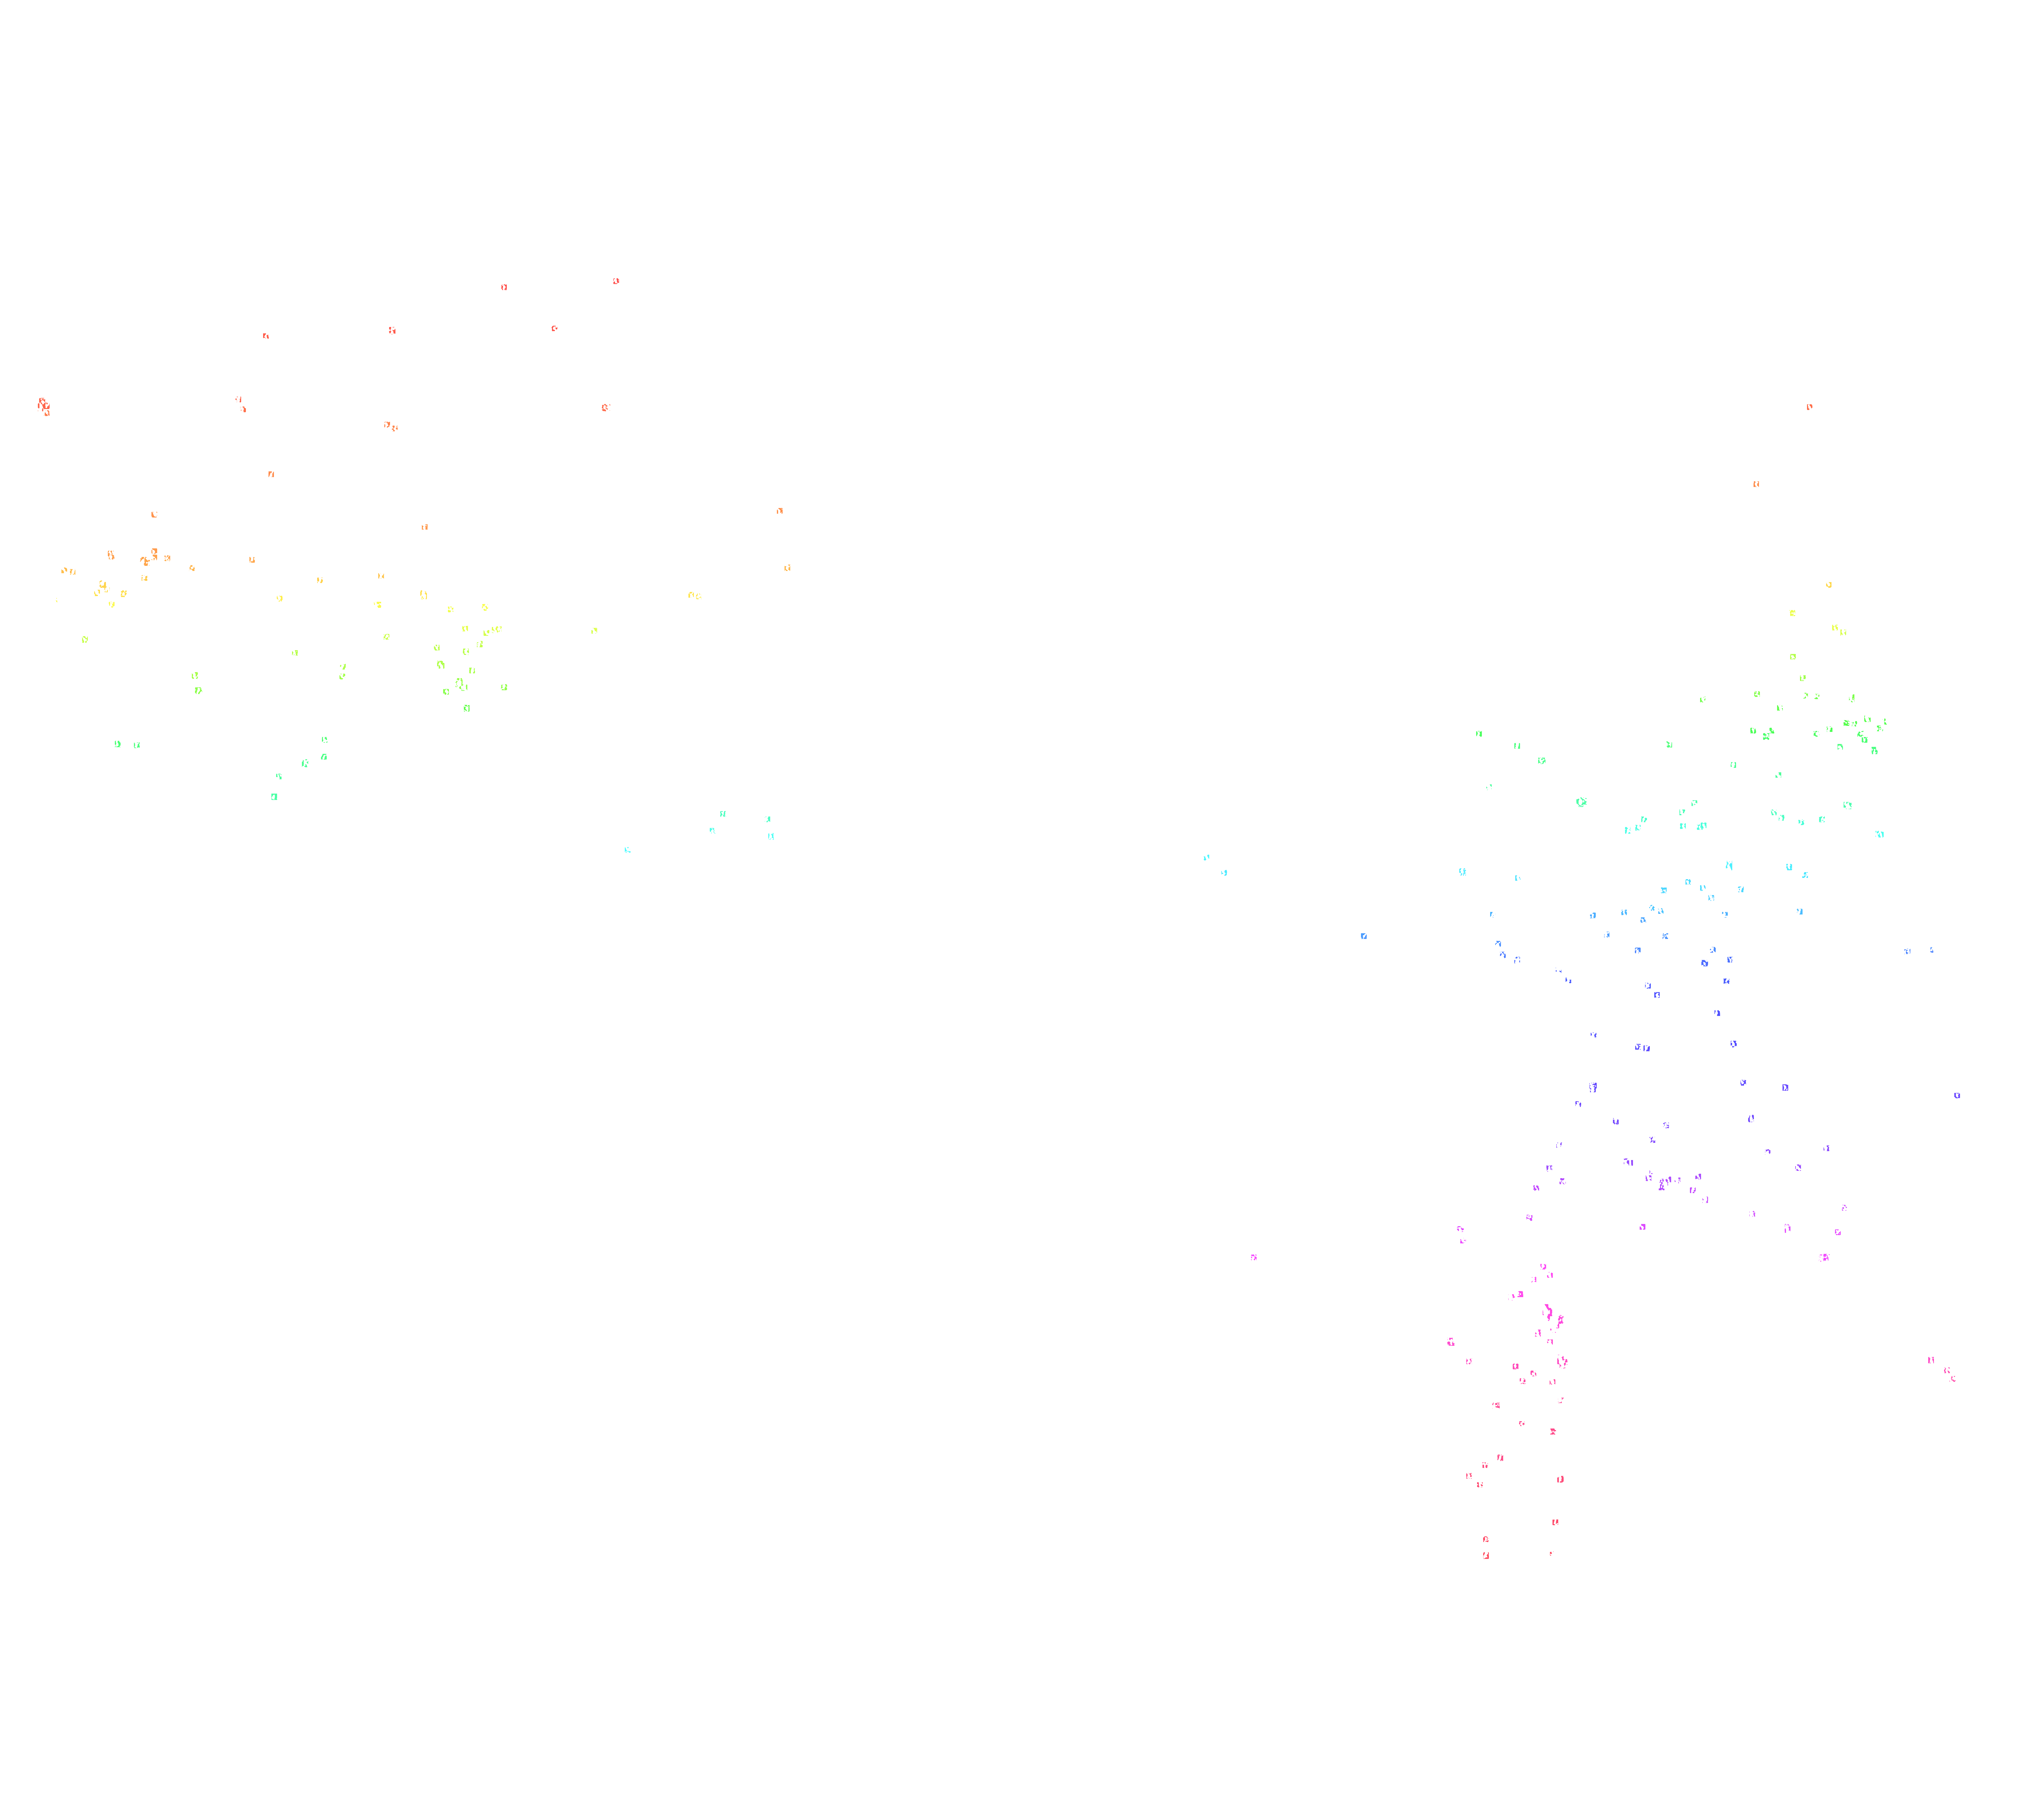

In [22]:
# =====================================================================
# PASSAGGIO 7: VISUALIZZAZIONE DEI PALEO CANALI SU IMMAGINE SATELLITARE
# =====================================================================

import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Aggiungi un layer satellitare di Google Maps come basemap
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Google Satellite',
    overlay=False,
    control=True
).add_to(m)

# Prepara labeled_array per folium.raster_layers.ImageOverlay
# Ricrea la colormap personalizzata
# Utilizza 'hsv' per una gamma ampia di tonalità per le componenti connesse.
base_cmap = plt.get_cmap('hsv', num_features + 1)
colors = base_cmap(np.arange(base_cmap.N))

# Imposta il primo colore (corrispondente a 0, il background) a bianco completamente opaco (RGBA)
colors[0] = np.array([1, 1, 1, 1])  # [R, G, B, Alpha]. Alpha = 1 per opacità totale

# Per le componenti (etichette > 0), imposta un'opacità parziale (es. 0.7)
# Questo creerà un effetto trasparente SOLO per i paleo-canali, non per lo sfondo.
for i in range(1, len(colors)): # Cicla da 1 in poi, escludendo il background
    colors[i][3] = 0.7 # Imposta l'alpha a 0.7 per le componenti connesse

new_cmap = mcolors.ListedColormap(colors)

# Converti labeled_array in un'immagine RGBA utilizzando la colormap personalizzata
# normalizzando i valori dell'array per la colormap e convertendo in uint8
rgba_image = new_cmap(labeled_array / np.max(labeled_array)) # Normalizza da 0 a 1
rgba_image_uint8 = (rgba_image * 255).astype(np.uint8) # Converti in uint8

# Aggiungi le componenti connesse come overlay
# L'opacità qui è 1 per l'intero overlay, ma le singole opacità sono gestite nell'RGBA_image.
folium.raster_layers.ImageOverlay(
    image=rgba_image_uint8, # Usa i dati dell'immagine RGBA
    bounds=(
        (lat_min, lon_min),
        (lat_max, lon_max)
    ),
    opacity=1.0, # Imposta a 1.0 per usare l'opacità definita all'interno dell'immagine RGBA
    name='Componenti Connesse (Flood Fill)'
).add_to(m)

# Aggiungi un controllo layer per attivare/disattivare i layer
folium.LayerControl().add_to(m)

# Visualizza la mappa aggiornata
m

Salviamo le elaborazioni ottenute in Mongo DB

In [31]:
import pymongo
import io
import datetime
from PIL import Image
from google.colab import userdata
import hashlib

# --- MongoDB Configuration ---
MONGODB_PASSWORD = userdata.get('MONGODB_PASSWORD')
MONGO_URI = "mongodb+srv://asaporiti_db_user:" + MONGODB_PASSWORD+ "@cluster0.yoy1y3m.mongodb.net/?appName=Cluster0";

DB_NAME = "paleo_channels_db"
COLLECTION_NAME = "images_and_bounds"

# --- Prepare Bounding Box Data ---
bounding_box_data = {
    "top_left": {"latitude": lat_max, "longitude": lon_min},
    "bottom_right": {"latitude": lat_min, "longitude": lon_max},
    "center": {"latitude": center_lat, "longitude": center_lon},
    "location_address": location.address if location else "Unknown"
}

# Convert the numpy array (rgba_image_uint8) to a PIL Image object
img_pil = Image.fromarray(rgba_image_uint8)

# Save the PIL Image to a byte stream in PNG format
img_byte_arr = io.BytesIO()
img_pil.save(img_byte_arr, format='PNG')
img_bytes = img_byte_arr.getvalue()

# Generate a unique ID using the MD5 hash of the image bytes
image_id = hashlib.md5(img_bytes).hexdigest()

print("Bounding box data and image bytes prepared.")

# --- Connect to MongoDB and Insert Data ---
try:
    client = pymongo.MongoClient(MONGO_URI)
    db = client[DB_NAME]
    collection = db[COLLECTION_NAME]

    # Document to insert/update
    document = {
        "_id": image_id,
        "bounding_box": bounding_box_data,
        "image_filename": f"paleo_channels_map_{image_id}.png",
        "image_data": img_bytes,
        "timestamp": datetime.datetime.now()
    }

    # Insert or update the document using upsert=True
    result = collection.update_one({'_id': image_id}, {'$set': document}, upsert=True)

    if result.upserted_id:
        print(f"New document inserted with ID: {result.upserted_id}")
    elif result.modified_count > 0:
        print(f"Document with ID: {image_id} updated.")
    else:
        print(f"Document with ID: {image_id} was already up-to-date or no changes were made.")

except pymongo.errors.ConnectionFailure as e:
    print(f"Could not connect to MongoDB: {e}")
    print("Please ensure MongoDB is running and your MONGO_URI is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
finally:
    if 'client' in locals() and client:
        client.close()
        print("MongoDB connection closed.")

Bounding box data and image bytes prepared.
Document with ID: 88ff3e8bcdb33582e15e575bf6763f0c updated.
MongoDB connection closed.
